# Tutorial: Load a Trained Network and Evaluate

Shows how to reload a model trained by `tuto_train.py` and:

1. Reconstruct the DataModule and model from the saved config
2. Load the best checkpoint
3. Compute per-channel $R^2$ and regression metrics
4. Visualize predicted vs ground-truth pressure fields

In [7]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from closure import ClosureDataModule, ClosureLitModule, MLP, load_paths
import closure.evaluation as ev
from closure.visualization import plot_pred_targets

## 1) Point to the training run

Set `run_dir` to the output folder produced by `tuto_train.py`.  
The config, checkpoints, and normalization files all live here.

In [ ]:
import os

# The config uses ./ relative paths that resolve against CWD.
# Ensure CWD is the project root so _resolve_path() works correctly.
project_root = Path(__file__).resolve().parents[2] if '__file__' in dir() else Path('..', '..').resolve()
os.chdir(project_root)
print('CWD set to:', Path.cwd())

paths = load_paths(str(project_root / 'paths.yaml'))
run_dir = Path(paths['work_dir']) / 'tuto'

config_path = run_dir / 'configs' / 'model.yaml'
ckpt_dir = run_dir / 'checkpoints'

print('run_dir    :', run_dir)
print('config_path:', config_path)
print('ckpt_dir   :', ckpt_dir)
assert config_path.exists(), f'Config not found: {config_path}'

CWD set to: /volume1/scratch/georgem/closure
run_dir    : /volume1/scratch/georgem/closure/models/tuto
config_path: /volume1/scratch/georgem/closure/models/tuto/configs/mlp.yaml
ckpt_dir   : /volume1/scratch/georgem/closure/models/tuto/checkpoints


## 2) Load config and rebuild DataModule + Model

The config stores `data_folder`, `norm_folder`, and sample file paths  
with `./` prefixes.  `ClosureDataModule._resolve_path()` resolves them  
against CWD (for `./`) or `paths.yaml` roots (bare identifiers).

In [9]:
with open(config_path) as f:
    cfg = yaml.safe_load(f)

data_cfg = cfg['data']
model_cfg = cfg['model']

# DataModule — paths resolved automatically via _resolve_path()
datamodule = ClosureDataModule(
    data_folder=data_cfg['data_folder'],
    norm_folder=data_cfg['norm_folder'],
    train_samples_file=data_cfg.get('train_samples_file'),
    val_samples_file=data_cfg.get('val_samples_file'),
    test_samples_file=data_cfg.get('test_samples_file'),
    batch_size=cfg['trainer']['batch_size'],
    num_workers=cfg['trainer']['num_workers'],
    flatten=data_cfg['flatten'],
    scaler_features=data_cfg['scaler_features'],
    scaler_targets=data_cfg['scaler_targets'],
    prescaler_features=data_cfg['prescaler_features'],
    prescaler_targets=data_cfg['prescaler_targets'],
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
)

# Rebuild the same network architecture
network = MLP(
    feature_dims=model_cfg['feature_dims'],
    activations=model_cfg['activations'],
)

print('DataModule and network created from config.')
print('Architecture:', model_cfg['feature_dims'])

DataModule and network created from config.
Architecture: [10, 60, 80, 50, 40, 6]


## 3) Load the best checkpoint

We pick the checkpoint with the lowest validation loss from the filename.

In [10]:
# Find the best checkpoint (lowest val_loss in filename)
ckpts = sorted(ckpt_dir.glob('epoch*.ckpt'))
if ckpts:
    best_ckpt = min(ckpts, key=lambda p: float(p.stem.split('val_loss')[-1].replace('=', '')))
else:
    best_ckpt = ckpt_dir / 'last.ckpt'

print('Loading checkpoint:', best_ckpt)
module = ClosureLitModule.load_from_checkpoint(str(best_ckpt), network=network)
module.eval()
print('Model loaded and set to eval mode.')

Loading checkpoint: /volume1/scratch/georgem/closure/models/tuto/checkpoints/epochepoch=002-vallossval_loss=0.6396.ckpt
Model loaded and set to eval mode.


## 4) Prepare test data

In [11]:
datamodule.setup('test')
print('test samples:', len(datamodule.test_dataset))
print('test features shape:', tuple(datamodule.test_dataset.features.shape))
print('test targets shape :', tuple(datamodule.test_dataset.targets.shape))
print('target channels    :', datamodule.test_dataset.request_targets)

Failed to read Pxy_0 from T2D13_tiny/T2D-Fields_003000.h5.pkl using path /volume1/scratch/georgem/closure/tests/fixtures/ecsim_tiny: 'Pxy_0'
Off-diagonal pressure Pxy_0 absent for species 'e'. Filling with zeros (shape (128, 128, 1)). If this field should be present, check your simulation output.
Failed to read Pxz_0 from T2D13_tiny/T2D-Fields_003000.h5.pkl using path /volume1/scratch/georgem/closure/tests/fixtures/ecsim_tiny: 'Pxz_0'
Off-diagonal pressure Pxz_0 absent for species 'e'. Filling with zeros (shape (128, 128, 1)). If this field should be present, check your simulation output.
Failed to read Pyz_0 from T2D13_tiny/T2D-Fields_003000.h5.pkl using path /volume1/scratch/georgem/closure/tests/fixtures/ecsim_tiny: 'Pyz_0'
Off-diagonal pressure Pyz_0 absent for species 'e'. Filling with zeros (shape (128, 128, 1)). If this field should be present, check your simulation output.
Failed to read Pxy_0 from T2D13_tiny/T2D-Fields_003500.h5.pkl using path /volume1/scratch/georgem/closure/

test samples: 32768
test features shape: (32768, 10)
test targets shape : (32768, 6)
target channels    : ['Pxx_e', 'Pyy_e', 'Pzz_e', 'Pxy_e', 'Pxz_e', 'Pyz_e']


## 5) Compute predictions

In [12]:
ground_truth, prediction = ev.transform_targets(
    module,
    datamodule.test_dataset,
    target_channels=datamodule.target_channels,
    rescale=False,
    renorm=False,
    verbose=False,
    reshape=False,
    test_features=datamodule.test_dataset.features,
)

print('prediction   shape:', prediction.shape)
print('ground_truth shape:', ground_truth.shape)

prediction   shape: (32768, 6)
ground_truth shape: (32768, 6)


## 6) Per-channel $R^2$ and regression metrics

In [13]:
metrics_df = ev.evaluate_regression_metrics(
    datamodule.test_dataset,
    ground_truth,
    prediction,
    target_channels=datamodule.target_channels,
)

display(metrics_df.sort_values('r2', ascending=False))

,channel_index,channel,mse,rmse,mae,r2,pearson_r,mean_abs_ground_truth,nrmse
5,5,Pyz_e,0.773127,0.879276,0.562915,0.752206,0.888433,1.378861,0.637683
1,1,Pyy_e,3.000484,1.732190,1.472301,0.668690,0.900256,3.114464,0.556176
2,2,Pzz_e,2.563498,1.601093,1.326005,0.445074,0.854446,2.144733,0.746523
3,3,Pxy_e,0.109883,0.331486,0.254844,0.421637,0.768669,0.781054,0.424409
4,4,Pxz_e,6.695322,2.587532,1.072971,0.419861,0.742967,2.037702,1.269828
0,0,Pxx_e,3.642872,1.908631,1.714654,0.307368,0.930784,2.954658,0.645974


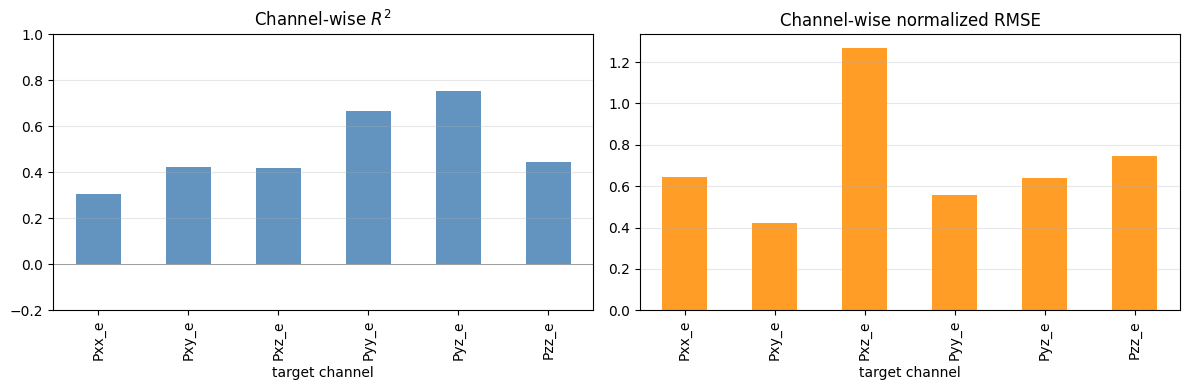

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms = metrics_df.set_index('channel').sort_index()

ms['r2'].plot.bar(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Channel-wise $R^2$')
axes[0].set_ylim(-0.2, 1.0)
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

ms['nrmse'].plot.bar(ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Channel-wise normalized RMSE')
axes[1].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xlabel('target channel')

plt.tight_layout()
plt.show()

## 7) Predicted vs ground-truth images

Diagonal pressures (e.g. $P_{xx}$) use a sequential colormap.  
Off-diagonal pressures ($P_{xy}$, etc.) are signed, so a diverging map is used.

In [15]:
# Resolve data_folder for plotting (needs absolute path to build the spatial grid)
resolved_data_folder = str(
    ClosureDataModule._resolve_path(data_cfg['data_folder'], 'data_dir')
)

n_timesteps = datamodule.test_dataset.targets_shape[0]
plot_indices = [i for i in [0, 1, 2] if i < n_timesteps]

print('Plotting timestep indices:', plot_indices)
print('Resolved data folder     :', resolved_data_folder)

Plotting timestep indices: [0, 1]
Resolved data folder     : /volume1/scratch/georgem/closure/tests/fixtures/ecsim_tiny


invfunc = <ufunc 'exp'>


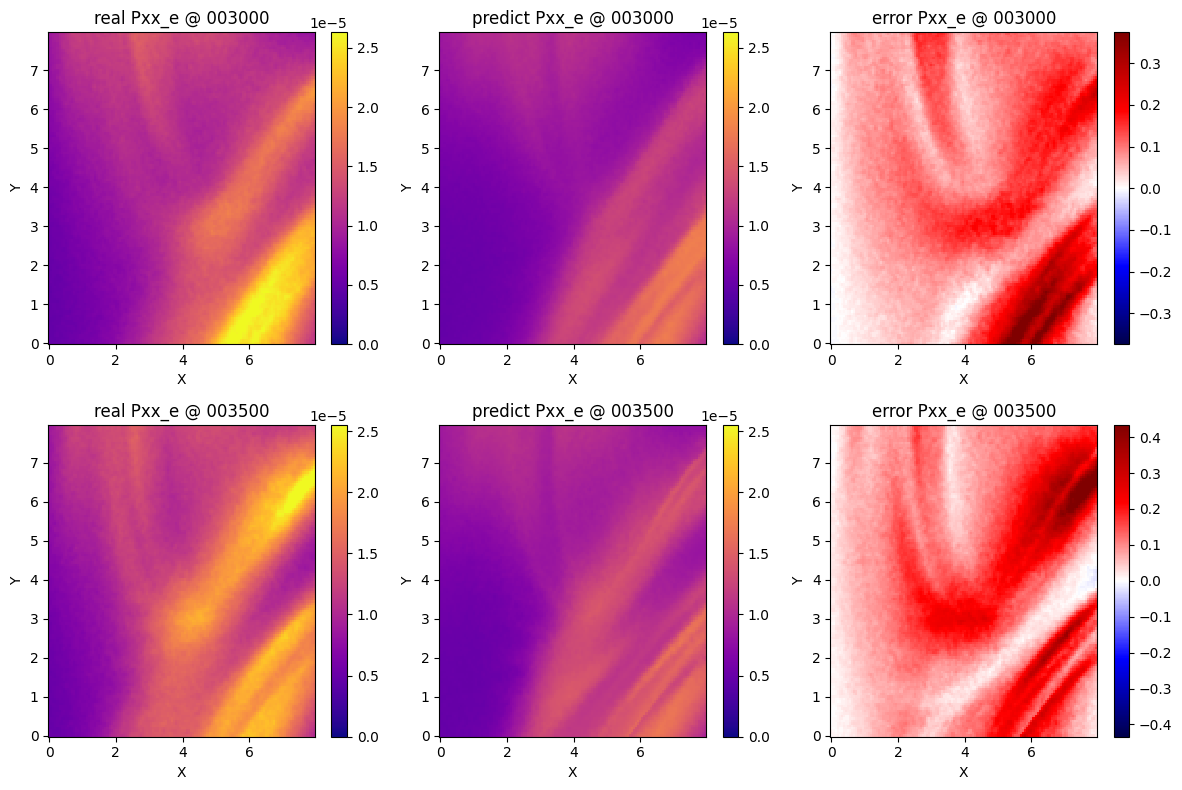

In [16]:
# Diagonal pressure component
plot_pred_targets(
    datamodule.test_dataset,
    'Pxx_e',
    prediction,
    ground_truth,
    data_folder=resolved_data_folder,
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
    target_channels=datamodule.target_channels,
    output_dir=str(run_dir),
    plot_indices=plot_indices,
    figsize=(12, 8),
    robust_quantile=0.995,
    error_mode='relative',
    signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'],
)

invfunc = <function plot_pred_targets.<locals>.<lambda> at 0x7fe3a932d440>


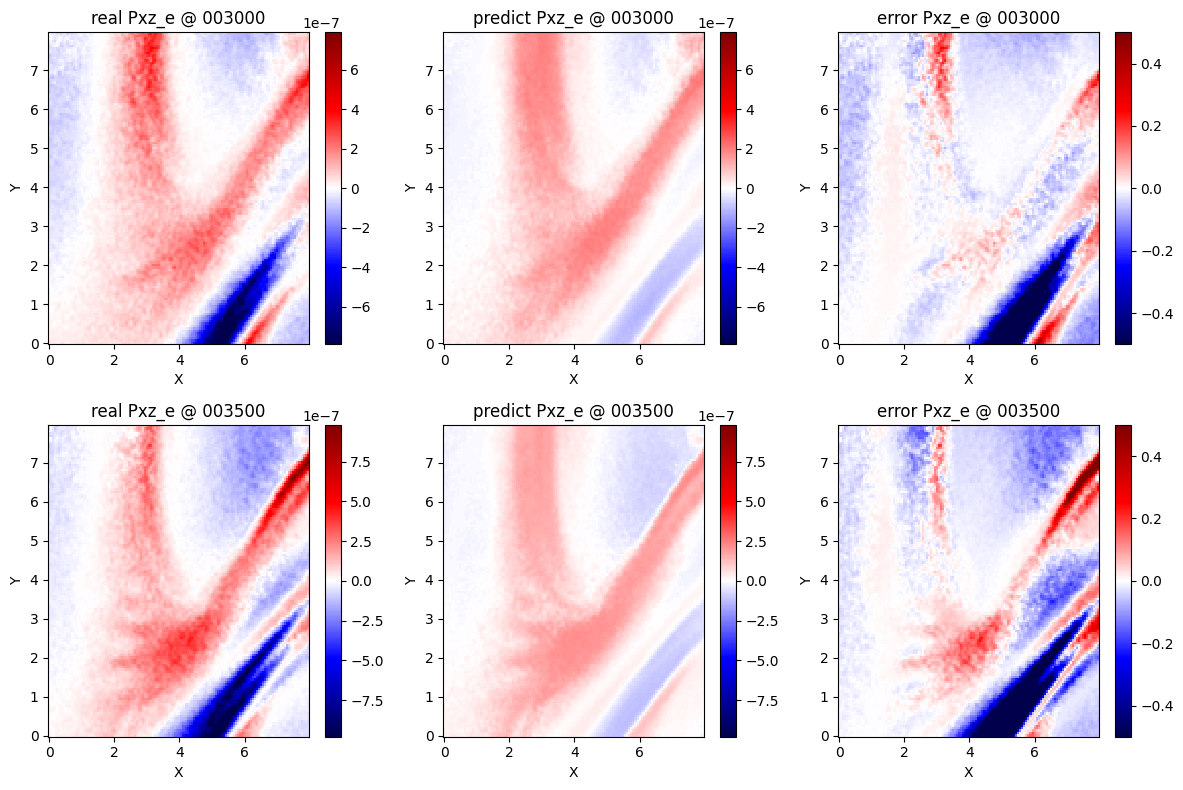

Plotted: Pxz_e


In [17]:
# Off-diagonal pressure component (signed → diverging colormap)
offdiag = 'Pxz_e' if 'Pxz_e' in datamodule.test_dataset.request_targets else datamodule.test_dataset.request_targets[0]

plot_pred_targets(
    datamodule.test_dataset,
    offdiag,
    prediction,
    ground_truth,
    data_folder=resolved_data_folder,
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
    target_channels=datamodule.target_channels,
    output_dir=str(run_dir),
    plot_indices=plot_indices,
    figsize=(12, 8),
    robust_quantile=0.995,
    error_mode='symmetric_percent',
    error_limit=0.5,
    signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'],
)
print('Plotted:', offdiag)

## 8) Quick scatter: predicted vs true (aggregated)

A 1:1 scatter plot gives a fast visual sense of how well the model tracks the ground truth.

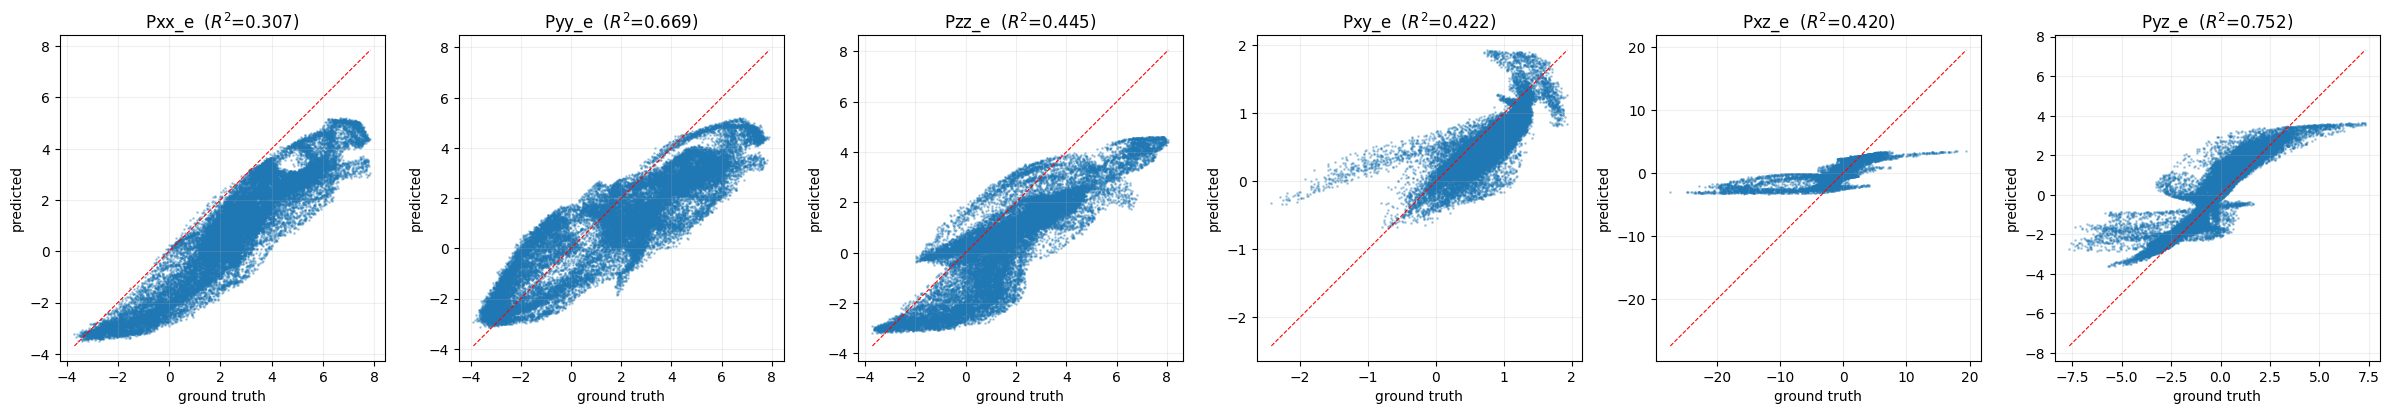

In [18]:
channels = datamodule.test_dataset.request_targets
n_ch = len(channels)
fig, axes = plt.subplots(1, n_ch, figsize=(4 * n_ch, 4), squeeze=False)

gt_np = np.asarray(ground_truth)
pred_np = np.asarray(prediction)

for idx, ch_name in enumerate(channels):
    ax = axes[0, idx]
    y = gt_np[:, idx].ravel()
    yhat = pred_np[:, idx].ravel()
    ax.scatter(y, yhat, s=1, alpha=0.3)
    lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]
    ax.plot(lims, lims, 'r--', linewidth=0.8, label='1:1')
    ax.set_xlabel('ground truth')
    ax.set_ylabel('predicted')
    ax.set_title(f'{ch_name}  ($R^2$={metrics_df.loc[metrics_df.channel == ch_name, "r2"].values[0]:.3f})')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()